In [55]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
import seaborn as sns
import libpysal
import esda
import spreg
import numpy as np
import os 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.colors as mcolors
import statsmodels.api as sm

In [56]:
# --- Fungsi Pembantu ---
def calculate_vif(X_df):
    """Menghitung VIF untuk setiap fitur di X_df"""
    vif = pd.DataFrame()
    vif["variables"] = X_df.columns
    vif["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
    return vif

def find_column_by_keywords(df, keywords, fallback_index=3):
    """Mencari nama kolom berdasarkan kata kunci atau fallback ke indeks."""
    for col in df.columns:
        if all(keyword in col.lower() for keyword in keywords):
            return col
    if len(df.columns) > fallback_index:
        print(f"Warning: Could not find column by keywords: {keywords}. Using fallback index {fallback_index}: {df.columns[fallback_index]}")
        return df.columns[fallback_index]
    raise ValueError(f"Column with keywords '{keywords}' or at fallback index {fallback_index} not found.")

In [57]:
# --- Konfigurasi Path Direktori ---
BASE_DIR = r"C:/Uner/Lomba/Nacoesta" # Gunakan raw string untuk path Windows

# Nama file (sesuai dengan yang Anda berikan)
trade_partnerships_file = "distribution-of-bilateral-and-unilateral-trade-partnerships.csv"
exports_file = "exports-of-goods-and-services-constant-2010-us.csv"
fdi_outflows_file = "foreign-direct-investment-net-outflows-as-share-of-gdp.csv"
gdp_per_capita_file = "gdp-per-capita-worldbank.csv"
shapefile_name = "ne_10m_admin_0_countries.shp"

In [58]:
# --- Tahap 1: Memuat dan Memproses Awal Data CSV ---
print("--- Memuat dan Memproses Awal Data CSV ---")
try:
    tp_df = pd.read_csv(os.path.join(BASE_DIR, trade_partnerships_file))
    ex_df = pd.read_csv(os.path.join(BASE_DIR, exports_file))
    fdi_df = pd.read_csv(os.path.join(BASE_DIR, fdi_outflows_file))
    gdp_df = pd.read_csv(os.path.join(BASE_DIR, gdp_per_capita_file))
    print("Berhasil memuat semua file CSV.")
except FileNotFoundError as e:
    print(f"Error: Salah satu file CSV tidak ditemukan. Pastikan path dan nama file benar. Detail: {e}")
    raise

# Identifikasi dinamis nama kolom data utama
gdp_col_orig = find_column_by_keywords(gdp_df, ['gdp per capita'])
trade_col_orig = find_column_by_keywords(tp_df, ['trade', 'partnership']) # atau 'distribution', 'bilateral'
exports_col_orig = find_column_by_keywords(ex_df, ['exports', 'goods'])
fdi_col_orig = find_column_by_keywords(fdi_df, ['foreign', 'direct', 'investment', 'outflows']) # atau 'fdi'

# Penggantian nama kolom
gdp_df.rename(columns={'Entity': 'Country', 'Code': 'Country_Code', 'Year': 'Year', gdp_col_orig: 'GDP_Per_Capita'}, inplace=True)
tp_df.rename(columns={'Entity': 'Country', 'Code': 'Country_Code', 'Year': 'Year', trade_col_orig: 'Trade_Partnerships_Count'}, inplace=True)
ex_df.rename(columns={'Entity': 'Country', 'Code': 'Country_Code', 'Year': 'Year', exports_col_orig: 'Exports_USD_2010'}, inplace=True)
fdi_df.rename(columns={'Entity': 'Country', 'Code': 'Country_Code', 'Year': 'Year', fdi_col_orig: 'FDI_Outflows_GDP_Percent'}, inplace=True)

# Pilih kolom yang diperlukan sebelum merge
gdp_df = gdp_df[['Country', 'Country_Code', 'Year', 'GDP_Per_Capita']].copy()
tp_df = tp_df[['Country', 'Country_Code', 'Year', 'Trade_Partnerships_Count']].copy()
ex_df = ex_df[['Country', 'Country_Code', 'Year', 'Exports_USD_2010']].copy()
fdi_df = fdi_df[['Country', 'Country_Code', 'Year', 'FDI_Outflows_GDP_Percent']].copy()

# Penggabungan data CSV
economic_df = pd.merge(gdp_df, tp_df, on=['Country', 'Country_Code', 'Year'], how='outer')
economic_df = pd.merge(economic_df, ex_df, on=['Country', 'Country_Code', 'Year'], how='outer')
economic_df = pd.merge(economic_df, fdi_df, on=['Country', 'Country_Code', 'Year'], how='outer')

print(f"Shape data ekonomi setelah merge awal: {economic_df.shape}")

--- Memuat dan Memproses Awal Data CSV ---
Berhasil memuat semua file CSV.
Shape data ekonomi setelah merge awal: (10417, 7)


In [59]:
# Penanganan nilai hilang awal
economic_df.dropna(subset=['GDP_Per_Capita'], inplace=True)
economic_df.dropna(subset=['Country_Code'], inplace=True) # Penting untuk merge dengan data spasial
print(f"Shape setelah drop NaN GDP_Per_Capita & Country_Code: {economic_df.shape}")

# Imputasi untuk kolom fitur lainnya
for col in ['Trade_Partnerships_Count', 'Exports_USD_2010', 'FDI_Outflows_GDP_Percent']:
    if col in economic_df.columns and economic_df[col].isnull().any():
        median_val = economic_df[col].median()
        economic_df[col].fillna(median_val, inplace=True)
        print(f"Imputasi NaNs di {col} dengan median ({median_val}).")

economic_df['Year'] = pd.to_numeric(economic_df['Year'], errors='coerce')
economic_df.dropna(subset=['Year'], inplace=True)
economic_df['Year'] = economic_df['Year'].astype(int)

print(f"Shape data ekonomi akhir yang diproses: {economic_df.shape}")
print("Data CSV selesai diproses.\n")
# economic_df.to_csv(os.path.join(BASE_DIR, "preprocessed_economic_data_combined.csv"), index=False) # Opsional: simpan



Shape setelah drop NaN GDP_Per_Capita & Country_Code: (6605, 7)
Imputasi NaNs di Trade_Partnerships_Count dengan median (9918.0).
Imputasi NaNs di Exports_USD_2010 dengan median (12355048401.5).
Imputasi NaNs di FDI_Outflows_GDP_Percent dengan median (0.28127466).
Shape data ekonomi akhir yang diproses: (6605, 7)
Data CSV selesai diproses.



C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_1724\1130943225.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  economic_df[col].fillna(median_val, inplace=True)
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_1724\1130943225.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [60]:
# --- Tahap 2: Memuat Data Spasial dan Menggabungkan ---
print("--- Memuat Data Spasial dan Menggabungkan ---")
try:
    world_gdf = geopandas.read_file(os.path.join(BASE_DIR, shapefile_name))
    print("Berhasil memuat shapefile.")
    print(f"Shape data spasial: {world_gdf.shape}")
except Exception as e: # Lebih umum untuk menangkap berbagai error dari geopandas
    print(f"Error memuat shapefile: {e}")
    print("Pastikan file shapefile (termasuk .dbf, .shx) ada di direktori yang benar.")
    raise

# Identifikasi kunci merge di data spasial
merge_key_geo = None
possible_geo_keys = ['ISO_A3_EH', 'ADM0_A3', 'GU_A3', 'SU_A3', 'ISO_A3'] # Urutan prioritas
for key in possible_geo_keys:
    if key in world_gdf.columns:
        merge_key_geo = key
        print(f"Menggunakan '{merge_key_geo}' dari data spasial untuk merge.")
        break
if not merge_key_geo:
    raise ValueError(f"Tidak ditemukan kolom kode ISO A3 yang cocok di shapefile. Kolom tersedia: {world_gdf.columns}")

# Standarisasi kode negara untuk merge
economic_df['Country_Code'] = economic_df['Country_Code'].str.upper()
world_gdf[merge_key_geo] = world_gdf[merge_key_geo].str.upper()

# Pilih tahun terbaru untuk analisis cross-sectional
latest_year = economic_df['Year'].max()
print(f"Menggunakan data tahun: {latest_year} untuk analisis.")
economic_selected_year_df = economic_df[economic_df['Year'] == latest_year].copy()

# Merge data ekonomi tahun terpilih dengan data spasial
merged_gdf = world_gdf.merge(economic_selected_year_df,
                             left_on=merge_key_geo,
                             right_on='Country_Code',
                             how='inner')

print(f"Shape GeoDataFrame hasil merge untuk tahun {latest_year}: {merged_gdf.shape}")
if merged_gdf.empty:
    raise ValueError("Merge menghasilkan GeoDataFrame kosong. Periksa kunci merge dan ketersediaan data.")

# Pastikan tidak ada NaN di variabel kunci regresi setelah merge
key_regression_cols = ['GDP_Per_Capita', 'Trade_Partnerships_Count', 'Exports_USD_2010', 'FDI_Outflows_GDP_Percent']
merged_gdf.dropna(subset=key_regression_cols, inplace=True)
merged_gdf = merged_gdf[merged_gdf.geometry.is_valid & ~merged_gdf.geometry.is_empty] # Jaga geometri valid
merged_gdf = merged_gdf.reset_index(drop=True) # Reset index penting untuk bobot spasial
print(f"Shape setelah drop NaN var. regresi & validasi geometri: {merged_gdf.shape}")

if merged_gdf.empty:
    raise ValueError("GeoDataFrame kosong setelah penanganan NaN akhir.")

print("Penggabungan data ekonomi dan spasial selesai.\n")

--- Memuat Data Spasial dan Menggabungkan ---
Berhasil memuat shapefile.
Shape data spasial: (258, 169)
Menggunakan 'ISO_A3_EH' dari data spasial untuk merge.
Menggunakan data tahun: 2023 untuk analisis.
Shape GeoDataFrame hasil merge untuk tahun 2023: (196, 176)
Shape setelah drop NaN var. regresi & validasi geometri: (195, 176)
Penggabungan data ekonomi dan spasial selesai.



--- Membuat Peta Tematik PDB per Kapita ---
Peta tematik dengan border '#563298' disimpan sebagai gdp_per_capita_map_border_563298.png di C:/Uner/Lomba/Nacoesta



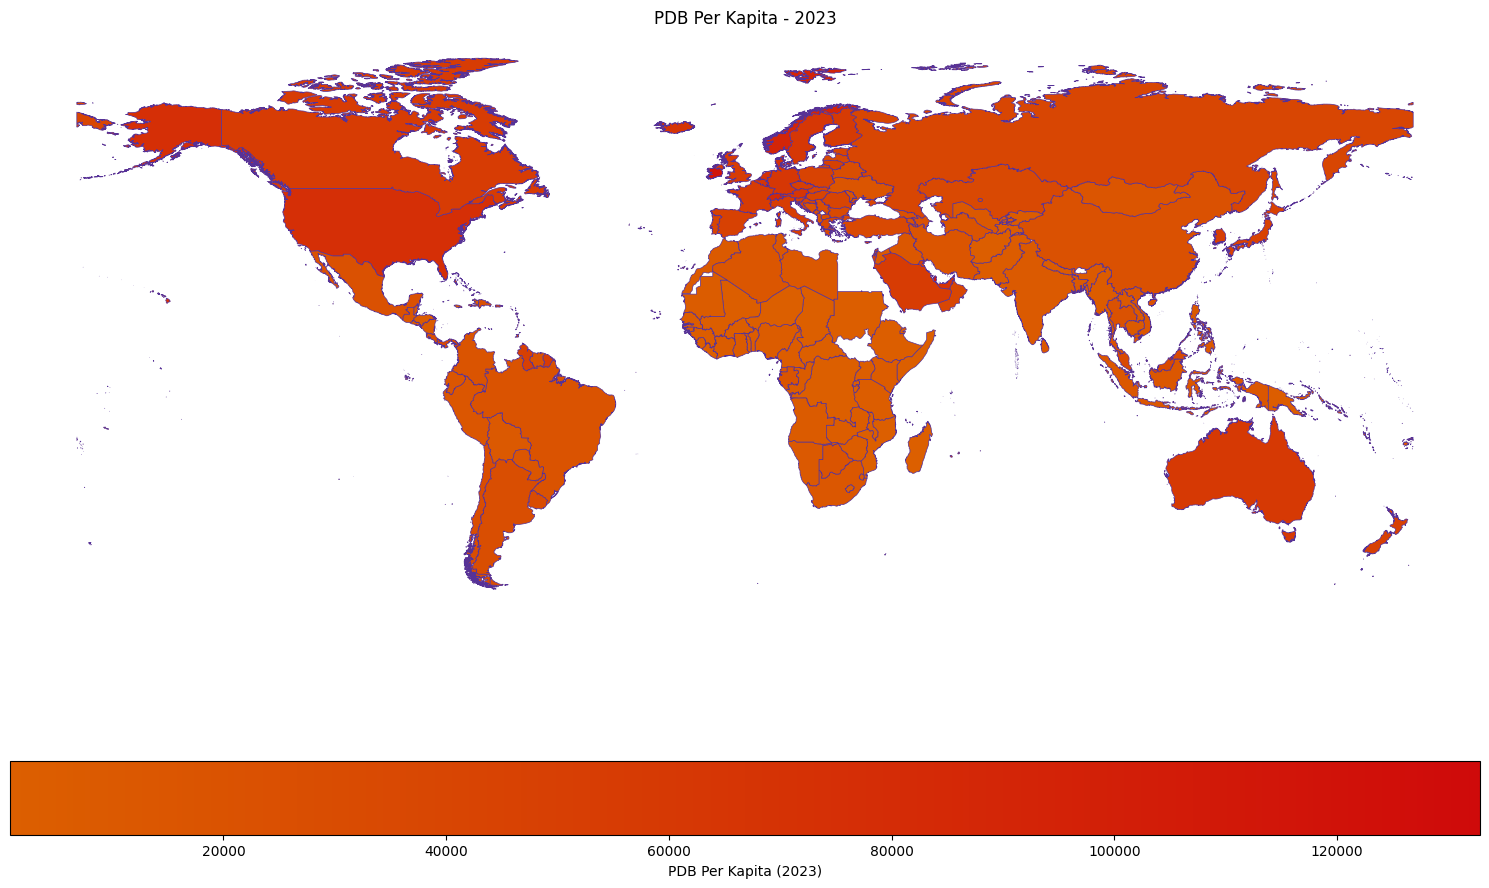

In [61]:
# --- Tahap 3: Visualisasi Peta Tematik ---
print("--- Membuat Peta Tematik PDB per Kapita ---")

# Definisikan warna untuk gradasi kustom (fill color)
color_start = '#DC5F00'
color_end = '#CF0A0A'

# Buat colormap kustom untuk fill
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [color_start, color_end])

# Definisikan warna border baru
new_border_color = '#563298'

fig, ax = plt.subplots(1, 1, figsize=(15, 10))
merged_gdf.plot(column='GDP_Per_Capita',
                ax=ax,
                legend=True,
                cmap=custom_cmap,
                edgecolor=new_border_color,  # Gunakan warna border baru di sini
                linewidth=0.5,      # Opsional: sesuaikan ketebalan garis batas
                legend_kwds={'label': f"PDB Per Kapita ({latest_year})", 'orientation': "horizontal"})
ax.set_title(f'PDB Per Kapita - {latest_year}')
ax.set_axis_off()
plt.tight_layout()
# Nama file diubah untuk mencerminkan perubahan warna border
plt.savefig(os.path.join(BASE_DIR, "gdp_per_capita_map_border_563298.png"))
print(f"Peta tematik dengan border '{new_border_color}' disimpan sebagai gdp_per_capita_map_border_563298.png di {BASE_DIR}\n")
# plt.show() # Matikan untuk run otomatis, nyalakan jika interaktif

--- Membuat Peta Tematik PDB per Kapita ---
Peta tematik (tanpa legenda) dengan border '#563298' disimpan sebagai gdp_per_capita_map_no_legend.png di C:/Uner/Lomba/Nacoesta



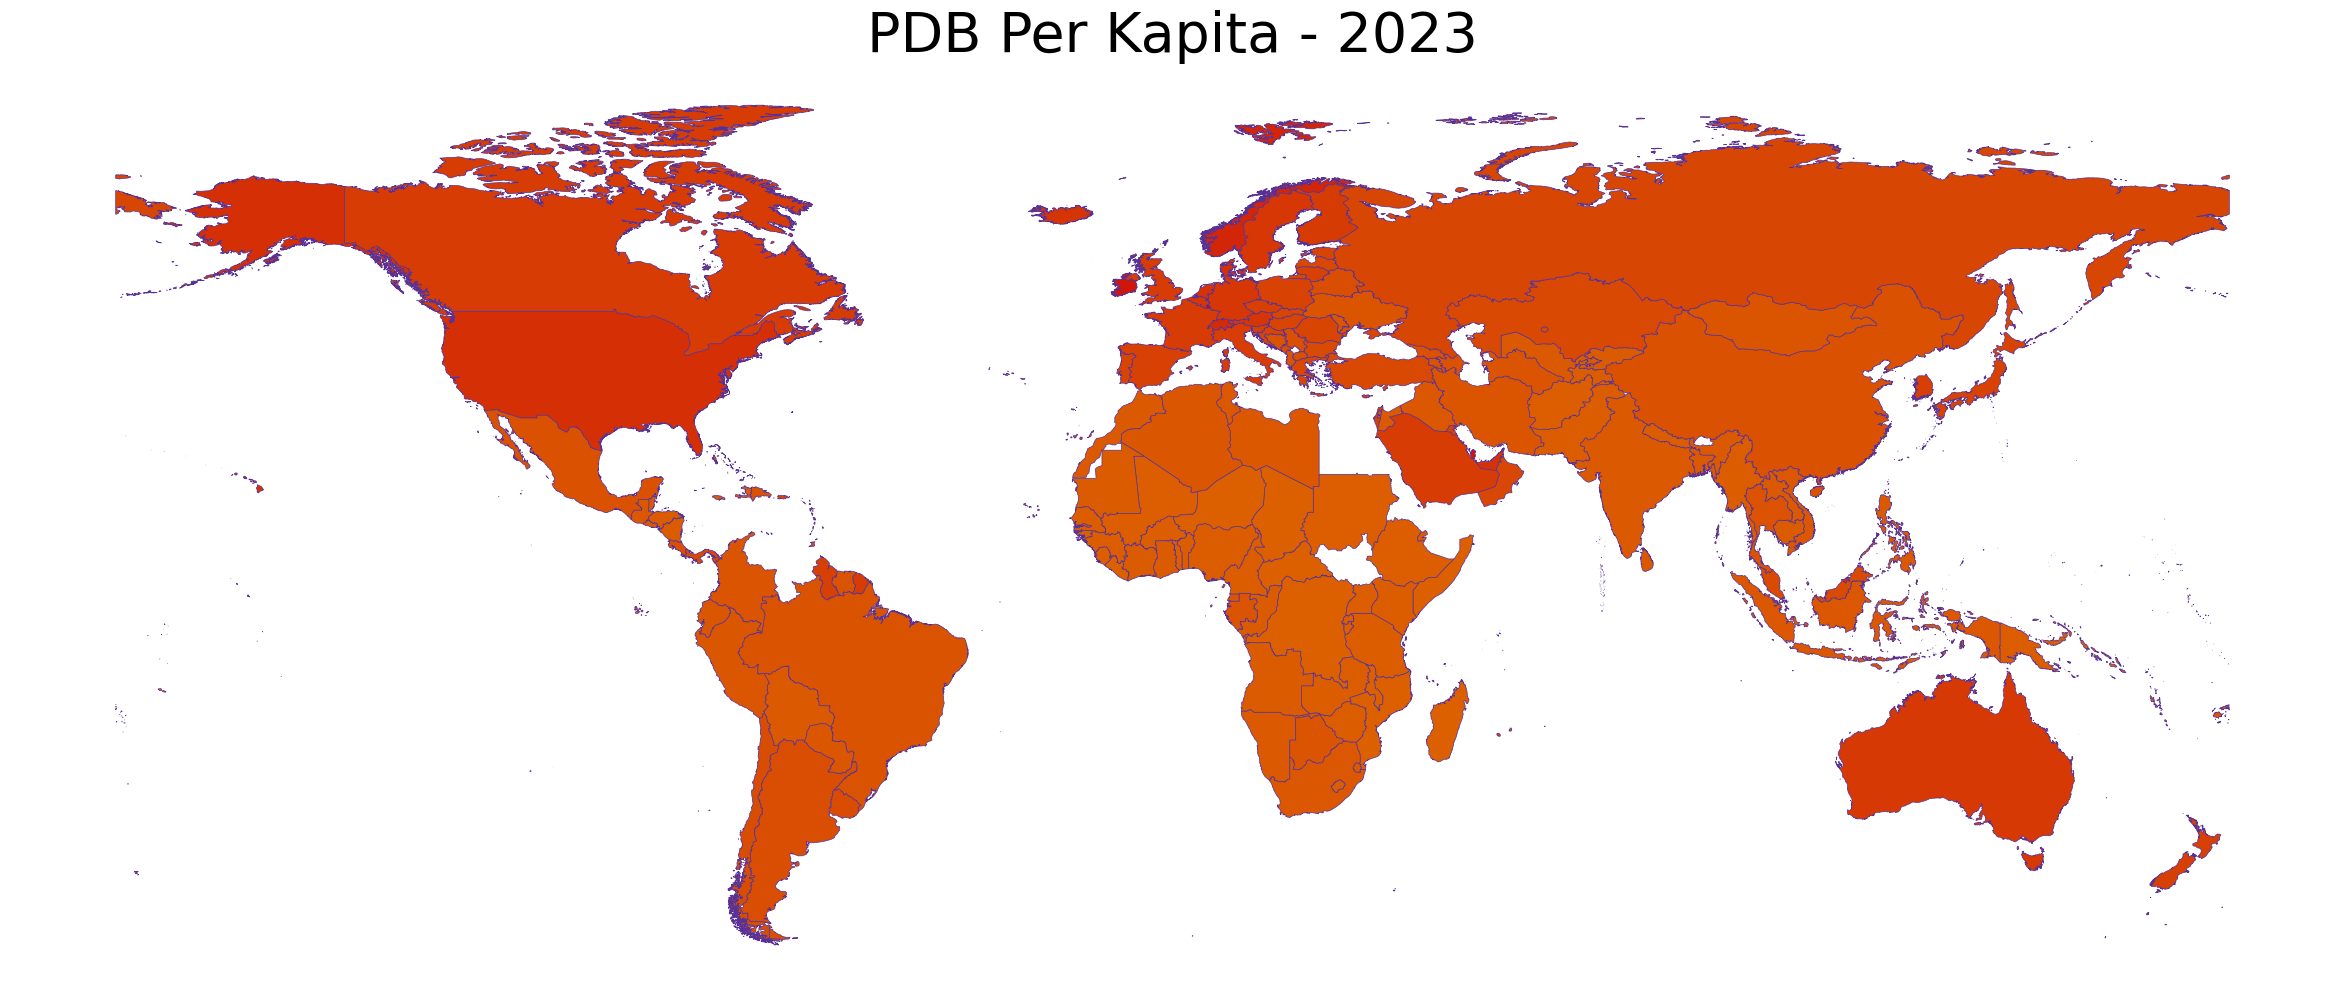

In [74]:
# --- Tahap 3: Visualisasi Peta Tematik ---
print("--- Membuat Peta Tematik PDB per Kapita ---")

# Definisikan warna untuk gradasi kustom (fill color)
color_start = '#DC5F00'
color_end = '#CF0A0A'

# Buat colormap kustom untuk fill
custom_cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", [color_start, color_end])

# Definisikan warna border baru
new_border_color = '#563298' # Sesuai permintaan terakhir Anda untuk border

fig, ax = plt.subplots(1, 1, figsize=(30, 20)) # figsize sangat besar, pastikan ini sesuai kebutuhan
merged_gdf.plot(column='GDP_Per_Capita',
                ax=ax,
                legend=False, # <--- UBAH INI MENJADI FALSE untuk menghilangkan legenda
                cmap=custom_cmap,
                edgecolor=new_border_color,
                linewidth=0.5) # legend_kwds dihilangkan karena legend=False
ax.set_title(f'PDB Per Kapita - {latest_year}', fontsize=40) # Ukuran font judul bisa disesuaikan dengan figsize
ax.set_axis_off()

# Nama file diubah untuk mencerminkan tidak adanya legenda
plt.savefig(os.path.join(BASE_DIR, "gdp_per_capita_map_nolegend.png"), dpi=100) # dpi bisa disesuaikan
print(f"Peta tematik (tanpa legenda) dengan border '{new_border_color}' disimpan sebagai gdp_per_capita_map_no_legend.png di {BASE_DIR}\n")
# plt.show()

In [62]:
# --- Tahap 4: Matriks Bobot Spasial (W) ---
print("--- Membuat Matriks Bobot Spasial ---")
try:
    # Gunakan kolom ID unik yang pasti ada setelah merge dan reset_index
    # Jika 'Country_Code' unik dan ada di merged_gdf, bisa digunakan.
    # Jika tidak, geopandas akan menggunakan index GeoDataFrame.
    if 'Country_Code' in merged_gdf.columns and merged_gdf['Country_Code'].is_unique:
        w = libpysal.weights.Queen.from_dataframe(merged_gdf, idVariable="Country_Code")
    else:
        print("Warning: 'Country_Code' tidak unik atau tidak ada, menggunakan index untuk idVariable.")
        merged_gdf['temp_id_for_weights'] = merged_gdf.index
        w = libpysal.weights.Queen.from_dataframe(merged_gdf, idVariable='temp_id_for_weights')

    w.transform = 'r' # Row-standardize
    print(f"Matriks bobot spasial (Queen) dibuat dengan {w.n} observasi.")
    print(f"Jumlah tetangga untuk 5 unit pertama: {[w.cardinalities[i] for i in range(min(5, w.n))]}\n")
except Exception as e:
    print(f"Error saat membuat matriks bobot spasial: {e}")
    raise

--- Membuat Matriks Bobot Spasial ---


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_1724\2714996426.py:12: FutureWarning: `idVariable` is deprecated and will be removed in future. Use `ids` instead.
  w = libpysal.weights.Queen.from_dataframe(merged_gdf, idVariable='temp_id_for_weights')


('WARNING: ', 6, ' is an island (no neighbors)')
('WARNING: ', 19, ' is an island (no neighbors)')
('WARNING: ', 29, ' is an island (no neighbors)')
('WARNING: ', 148, ' is an island (no neighbors)')
('WARNING: ', 149, ' is an island (no neighbors)')
('WARNING: ', 150, ' is an island (no neighbors)')
('WARNING: ', 151, ' is an island (no neighbors)')
('WARNING: ', 152, ' is an island (no neighbors)')
('WARNING: ', 153, ' is an island (no neighbors)')
('WARNING: ', 154, ' is an island (no neighbors)')
('WARNING: ', 155, ' is an island (no neighbors)')
('WARNING: ', 156, ' is an island (no neighbors)')
('WARNING: ', 157, ' is an island (no neighbors)')
('WARNING: ', 158, ' is an island (no neighbors)')
('WARNING: ', 159, ' is an island (no neighbors)')
('WARNING: ', 160, ' is an island (no neighbors)')
('WARNING: ', 161, ' is an island (no neighbors)')
('WARNING: ', 162, ' is an island (no neighbors)')
('WARNING: ', 163, ' is an island (no neighbors)')
('WARNING: ', 164, ' is an island (

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 53 disconnected components.
 There are 50 islands with ids: 6, 19, 29, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194.
  W.__init__(self, neighbors, ids=ids, **kw)


--- Menguji Autokorelasi Spasial (Moran's I) untuk PDB per Kapita ---
Moran's I global untuk PDB Per Kapita: 0.5939 (p-value: 0.0010)
Moran scatter plot disimpan sebagai moran_scatterplot_gdp.png di C:/Uner/Lomba/Nacoesta



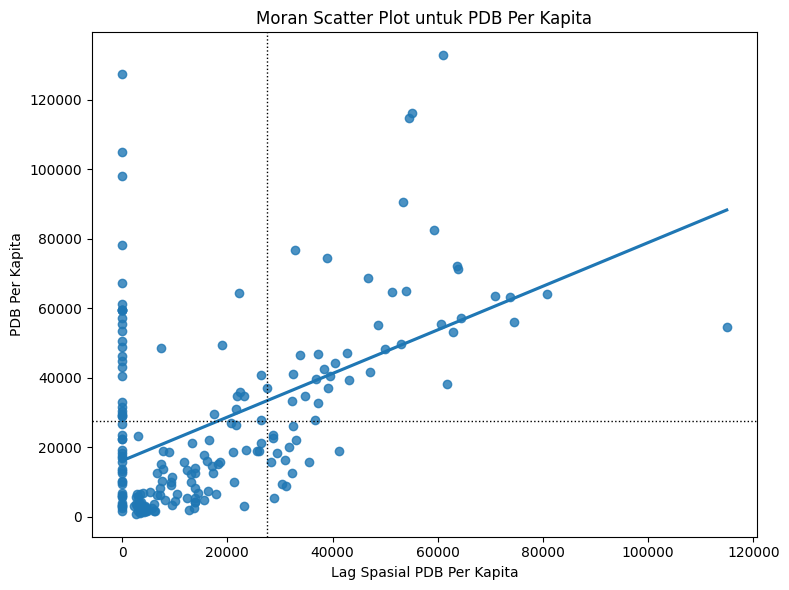

In [63]:
# --- Tahap 5: Uji Autokorelasi Spasial (Moran's I) ---
print("--- Menguji Autokorelasi Spasial (Moran's I) untuk PDB per Kapita ---")
y_spatial_test = merged_gdf['GDP_Per_Capita']
moran_global = esda.moran.Moran(y_spatial_test, w)
print(f"Moran's I global untuk PDB Per Kapita: {moran_global.I:.4f} (p-value: {moran_global.p_sim:.4f})")

# Plot Moran Scatter
fig, ax = plt.subplots(1, figsize=(8, 6))
sns.regplot(x=libpysal.weights.lag_spatial(w, y_spatial_test), y=y_spatial_test.values, ci=None, ax=ax)
ax.axvline(y_spatial_test.mean(), color='k', linestyle=':', lw=1)
ax.axhline(y_spatial_test.mean(), color='k', linestyle=':', lw=1)
ax.set_xlabel('Lag Spasial PDB Per Kapita')
ax.set_ylabel('PDB Per Kapita')
ax.set_title("Moran Scatter Plot untuk PDB Per Kapita")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "moran_scatterplot_gdp.png"))
print(f"Moran scatter plot disimpan sebagai moran_scatterplot_gdp.png di {BASE_DIR}\n")
plt.show()

In [64]:
# --- Tahap 6: Regresi OLS (Baseline) ---
print("--- Menjalankan Regresi OLS sebagai Baseline ---")

# Variabel dependen dan independen (sama seperti sebelumnya)
# Pastikan kolom yang digunakan ada di merged_gdf
required_cols_for_reg = ['GDP_Per_Capita', 'Trade_Partnerships_Count', 'Exports_USD_2010', 'FDI_Outflows_GDP_Percent']
if not all(col in merged_gdf.columns for col in required_cols_for_reg):
    missing = [col for col in required_cols_for_reg if col not in merged_gdf.columns]
    raise ValueError(f"Kolom berikut hilang dari merged_gdf dan diperlukan untuk regresi: {missing}")

merged_gdf.loc[:, 'Log_GDP_Per_Capita'] = np.log(merged_gdf['GDP_Per_Capita'].replace(0, 1e-9) + 1)
y_reg = merged_gdf['Log_GDP_Per_Capita'] # Gunakan nama variabel yang lebih generik untuk y

independent_vars = ['Trade_Partnerships_Count', 'Exports_USD_2010', 'FDI_Outflows_GDP_Percent']
X_reg = merged_gdf[independent_vars].copy()

# Pastikan semua kolom independen adalah numerik dan tidak ada NaN
for col in independent_vars:
    if X_reg[col].isnull().any():
        print(f"Peringatan: NaN ditemukan di kolom {col} dalam X_reg. Mengisi dengan median.")
        X_reg.loc[:, col] = X_reg[col].fillna(X_reg[col].median())
    if not pd.api.types.is_numeric_dtype(X_reg[col]):
        raise TypeError(f"Kolom {col} dalam X_reg bukan numerik.")

# Cek VIF
if X_reg.shape[1] > 1:
    try:
        vif_data = calculate_vif(X_reg.astype(float))
        print("--- Skor VIF untuk Prediktor ---")
        print(vif_data)
        if vif_data['VIF'].max() > 10:
            print("Peringatan: Multikolinearitas tinggi terdeteksi (VIF > 10).")
    except Exception as e_vif:
        print(f"Tidak dapat menghitung VIF: {e_vif}")

# Tambah konstanta menggunakan statsmodels.api
X_reg_const = sm.add_constant(X_reg.astype(float))

# Inisialisasi model
ols_model = None
ml_lag_model = None
ml_error_model = None

# Menjalankan OLS
print("\n--- 1. Model OLS ---")
try:
    # Pastikan y_reg dan X_reg_const memiliki panjang yang sama dan tidak ada NaN/Inf
    if y_reg.isnull().any() or np.isinf(y_reg).any():
        raise ValueError("NaN atau Inf ditemukan di y_reg (Log_GDP_Per_Capita).")
    if X_reg_const.isnull().any().any() or np.isinf(X_reg_const).any().any():
        raise ValueError("NaN atau Inf ditemukan di X_reg_const.")
    if len(y_reg) != len(X_reg_const):
        raise ValueError(f"Panjang y_reg ({len(y_reg)}) dan X_reg_const ({len(X_reg_const)}) tidak cocok.")

    ols_model = spreg.OLS(y_reg.values.reshape(-1,1), X_reg_const.values,
                          w=w, name_y='Log_GDP_Per_Capita',
                          name_x=X_reg_const.columns.tolist(),
                          spat_diag=True, moran=True)
    print(ols_model.summary)
    # Diagnostik spasial dari OLS tetap dicetak untuk informasi
    if hasattr(ols_model, 'rlm_lag') and hasattr(ols_model, 'rlm_error'):
        print("\nDiagnostik Spasial dari Residual OLS:")
        print(f"  Robust LM (lag) p-value: {ols_model.rlm_lag[1]:.4f}")
        print(f"  Robust LM (error) p-value: {ols_model.rlm_error[1]:.4f}")
    else:
        print("\nDiagnostik spasial (RLM) tidak tersedia untuk model OLS ini.")

except Exception as e:
    print(f"Error saat regresi OLS: {e}")
    print("Model OLS gagal dijalankan.")

--- Menjalankan Regresi OLS sebagai Baseline ---
--- Skor VIF untuk Prediktor ---
                  variables       VIF
0  Trade_Partnerships_Count  1.199088
1          Exports_USD_2010  1.000716
2  FDI_Outflows_GDP_Percent  1.000716

--- 1. Model OLS ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Log_GDP_Per_Capita                Number of Observations:         195
Mean dependent var  :      9.6628                Number of Variables   :           3
S.D. dependent var  :      1.1774                Degrees of Freedom    :         192
R-squared           :      0.1755
Adjusted R-squared  :      0.1669
Sum squared residual:     221.767                F-statistic           :     20.4281
Sigma-square        :       1.155                Prob(F-statistic)     :   9.047e-09
S.E. of regression  :       1.075                Log l

In [65]:
# --- Tahap 7: Regresi Spatial Lag Model (SAR/ML_Lag) ---
print("\n--- 2. Model Spatial Lag (ML_Lag / SAR) ---")
try:
    ml_lag_model = spreg.ML_Lag(y_reg.values.reshape(-1,1), X_reg_const.values, w=w,
                                name_y='Log_GDP_Per_Capita', name_x=X_reg_const.columns.tolist(),
                                vm=True) # vm=True untuk matriks varians-kovarians
    print(ml_lag_model.summary)
except Exception as e:
    print(f"Error saat regresi ML_Lag: {e}")
    print("Model ML_Lag gagal dijalankan.")


--- 2. Model Spatial Lag (ML_Lag / SAR) ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Log_GDP_Per_Capita                Number of Observations:         195
Mean dependent var  :      9.6628                Number of Variables   :           4
S.D. dependent var  :      1.1774                Degrees of Freedom    :         191
Pseudo R-squared    :      0.1766
Spatial Pseudo R-squared:  0.1833
Log likelihood      :   -289.0992
Sigma-square ML     :      1.1357                Akaike info criterion :     586.198
S.E of regression   :      1.0657                Schwarz criterion     :     599.290

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------

In [66]:
# --- Tahap 8: Regresi Spatial Error Model (SEM/ML_Error) ---
print("\n--- 3. Model Spatial Error (ML_Error / SEM) ---")
try:
    ml_error_model = spreg.ML_Error(y_reg.values.reshape(-1,1), X_reg_const.values, w=w,
                                    name_y='Log_GDP_Per_Capita', name_x=X_reg_const.columns.tolist(),
                                    vm=True) # vm=True untuk matriks varians-kovarians
    print(ml_error_model.summary)
except Exception as e:
    print(f"Error saat regresi ML_Error: {e}")
    print("Model ML_Error gagal dijalankan.")




--- 3. Model Spatial Error (ML_Error / SEM) ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
---------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Log_GDP_Per_Capita                Number of Observations:         195
Mean dependent var  :      9.6628                Number of Variables   :           3
S.D. dependent var  :      1.1774                Degrees of Freedom    :         192
Pseudo R-squared    :      0.1626
Log likelihood      :   -245.3914
Sigma-square ML     :      0.6236                Akaike info criterion :     496.783
S.E of regression   :      0.7897                Schwarz criterion     :     506.602

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
----------------------------------------------------------------------

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


In [67]:
# --- Tahap 9: Evaluasi dan Perbandingan Model ---
print("\n--- Evaluasi dan Perbandingan Model ---")
results_summary = []

if ols_model:
    try:
        ols_predy = ols_model.predy.flatten()
        ols_u = ols_model.u.flatten()
        ols_rmse = np.sqrt(np.mean(ols_u**2))
        results_summary.append({
            'Model': 'OLS',
            'R-squared': getattr(ols_model, 'r2', np.nan),
            'Adj. R-squared': getattr(ols_model, 'ar2', np.nan),
            'Log-Likelihood': getattr(ols_model, 'logll', np.nan),
            'AIC': getattr(ols_model, 'aic', np.nan),
            'BIC': getattr(ols_model, 'bic', np.nan),
            'RMSE': ols_rmse,
            'Sigma-squared (OLS)': getattr(ols_model, 'sig2', np.nan) # Varians error OLS
        })
        merged_gdf.loc[:, 'OLS_Residuals'] = ols_u
        merged_gdf.loc[:, 'OLS_Predicted'] = ols_predy
    except Exception as e_eval_ols:
        print(f"Error mengevaluasi OLS: {e_eval_ols}")


if ml_lag_model:
    try:
        ml_lag_predy = ml_lag_model.predy.flatten()
        ml_lag_u = ml_lag_model.u.flatten()
        ml_lag_rmse = np.sqrt(np.mean(ml_lag_u**2))
        results_summary.append({
            'Model': 'Spatial Lag (ML_Lag)',
            'Pseudo R-squared': getattr(ml_lag_model, 'pr2', np.nan),
            'Log-Likelihood': getattr(ml_lag_model, 'logll', np.nan),
            'AIC': getattr(ml_lag_model, 'aic', np.nan),
            'BIC': getattr(ml_lag_model, 'bic', np.nan),
            'RMSE': ml_lag_rmse,
            'Rho (Lag Coeff)': getattr(ml_lag_model, 'rho', [np.nan])[0], # Ambil nilai float
            'Sigma-squared (ML_Lag)': getattr(ml_lag_model, 'sig2', np.nan)
        })
        merged_gdf.loc[:, 'ML_Lag_Residuals'] = ml_lag_u
        merged_gdf.loc[:, 'ML_Lag_Predicted'] = ml_lag_predy
    except Exception as e_eval_lag:
        print(f"Error mengevaluasi ML_Lag: {e_eval_lag}")

if ml_error_model:
    try:
        ml_error_predy = ml_error_model.predy.flatten()
        ml_error_u = ml_error_model.u.flatten()
        ml_error_rmse = np.sqrt(np.mean(ml_error_u**2))
        results_summary.append({
            'Model': 'Spatial Error (ML_Error)',
            'Pseudo R-squared': getattr(ml_error_model, 'pr2', np.nan),
            'Log-Likelihood': getattr(ml_error_model, 'logll', np.nan),
            'AIC': getattr(ml_error_model, 'aic', np.nan),
            'BIC': getattr(ml_error_model, 'bic', np.nan),
            'RMSE': ml_error_rmse,
            'Lambda (Error Coeff)': getattr(ml_error_model, 'lamb', [np.nan])[0], # Ambil nilai float
            'Sigma-squared (ML_Error)': getattr(ml_error_model, 'sig2', np.nan)
        })
        merged_gdf.loc[:, 'ML_Error_Residuals'] = ml_error_u
        merged_gdf.loc[:, 'ML_Error_Predicted'] = ml_error_predy
    except Exception as e_eval_err:
        print(f"Error mengevaluasi ML_Error: {e_eval_err}")


if results_summary:
    comparison_df = pd.DataFrame(results_summary)
    print("\nTabel Perbandingan Model:")
    # Menampilkan semua kolom, mungkin perlu disesuaikan jika terlalu lebar
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print(comparison_df.set_index('Model').T) # Transpose untuk tampilan yang lebih baik
else:
    print("Tidak ada model yang berhasil dievaluasi untuk perbandingan.")


--- Evaluasi dan Perbandingan Model ---
Error mengevaluasi ML_Lag: invalid index to scalar variable.

Tabel Perbandingan Model:
Model                            OLS Spatial Error (ML_Error)
R-squared                   0.175457                      NaN
Adj. R-squared              0.166868                      NaN
Log-Likelihood           -289.234153              -245.391407
AIC                       584.468307               496.782815
BIC                              NaN                      NaN
RMSE                        1.066427                 1.133845
Sigma-squared (OLS)         1.155036                      NaN
Pseudo R-squared                 NaN                 0.162599
Lambda (Error Coeff)             NaN                      NaN
Sigma-squared (ML_Error)         NaN    [[0.623556869819574]]



--- Visualisasi Hasil Model ---

Membuat Peta Residual...
Peta residual OLS disimpan sebagai OLS_residuals_map_customstyle.png
Peta residual ML_Error disimpan sebagai ML_Error_residuals_map_customstyle.png

Membuat Plot Prediksi vs. Aktual...
Plot Prediksi vs. Aktual OLS disimpan sebagai OLS_predicted_vs_actual.png
Plot Prediksi vs. Aktual ML_Error disimpan sebagai ML_Error_predicted_vs_actual.png

--- Analisis Selesai (termasuk OLS, SAR, SEM, evaluasi, dan visualisasi dengan gaya peta yang disesuaikan) ---
Output dan plot disimpan di direktori: C:/Uner/Lomba/Nacoesta


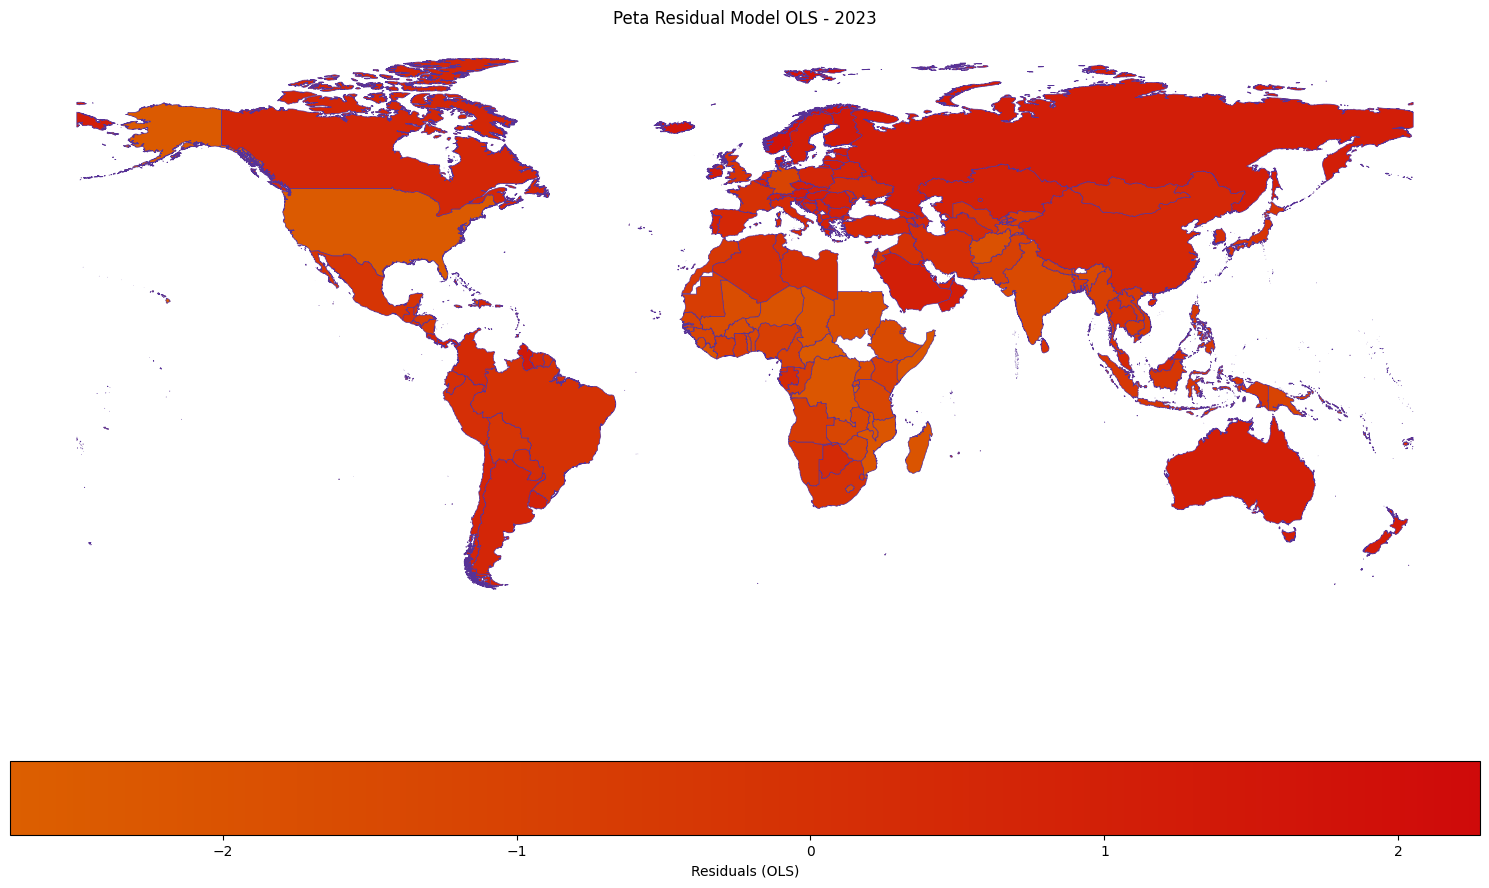

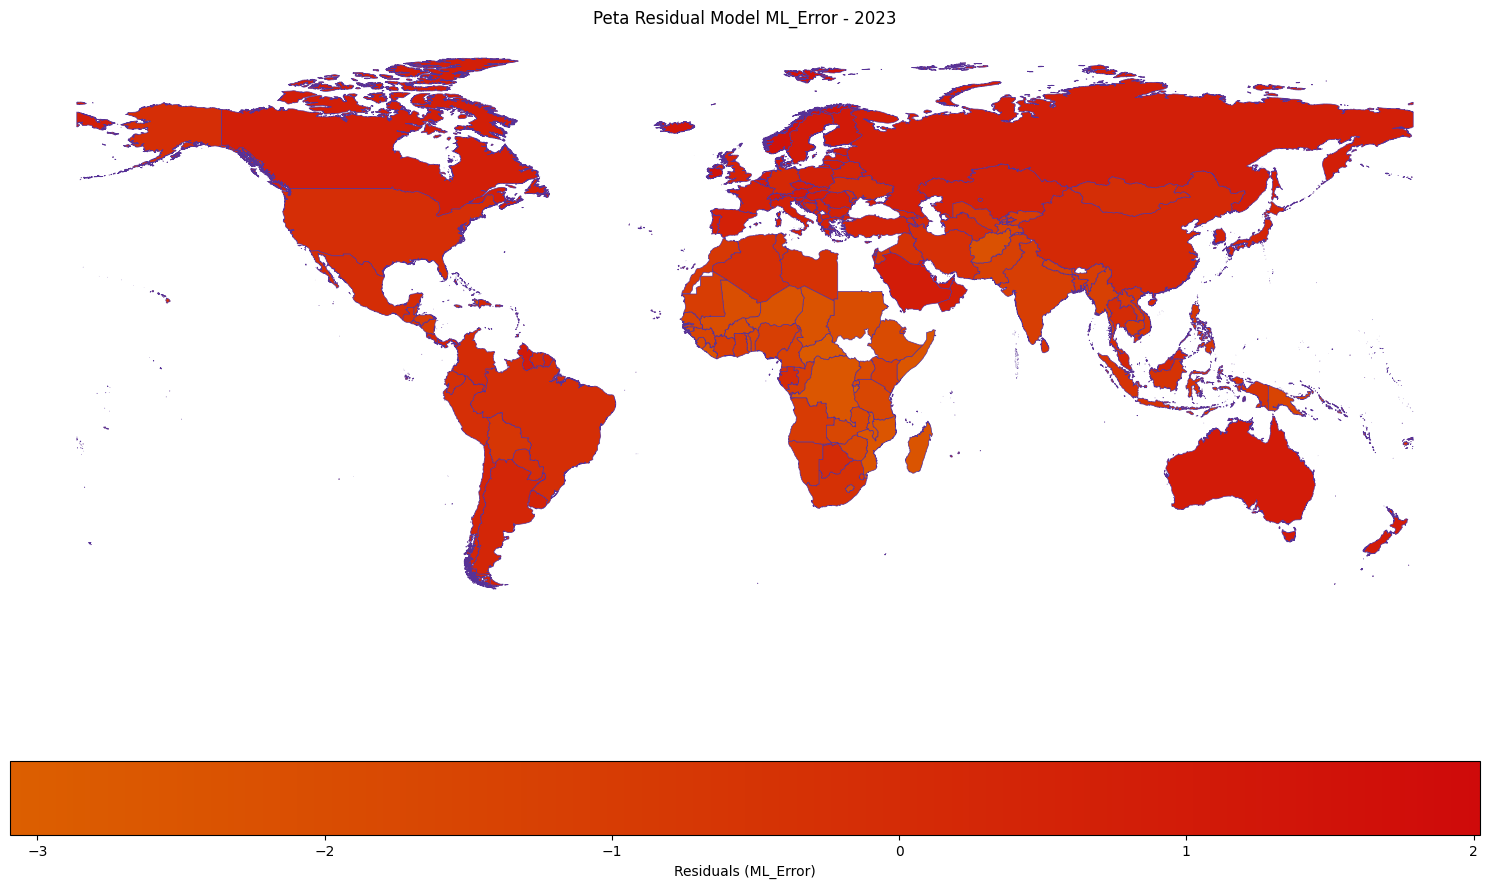

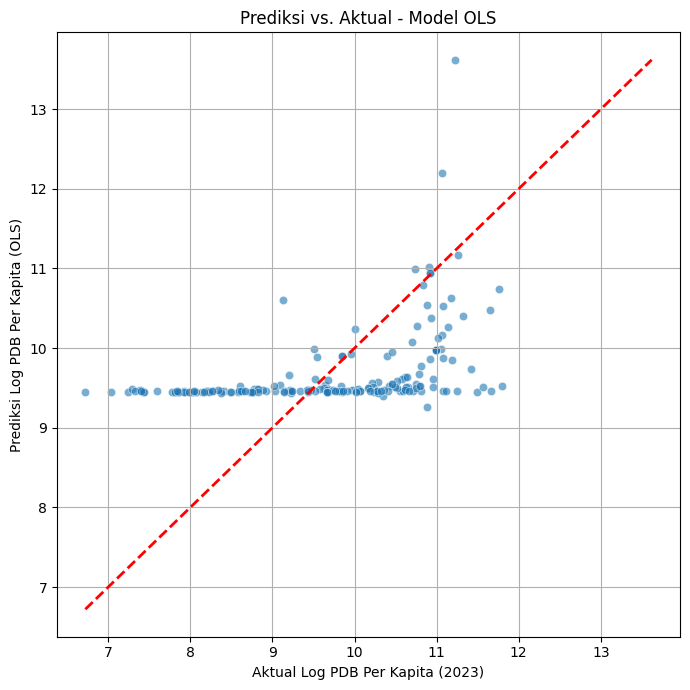

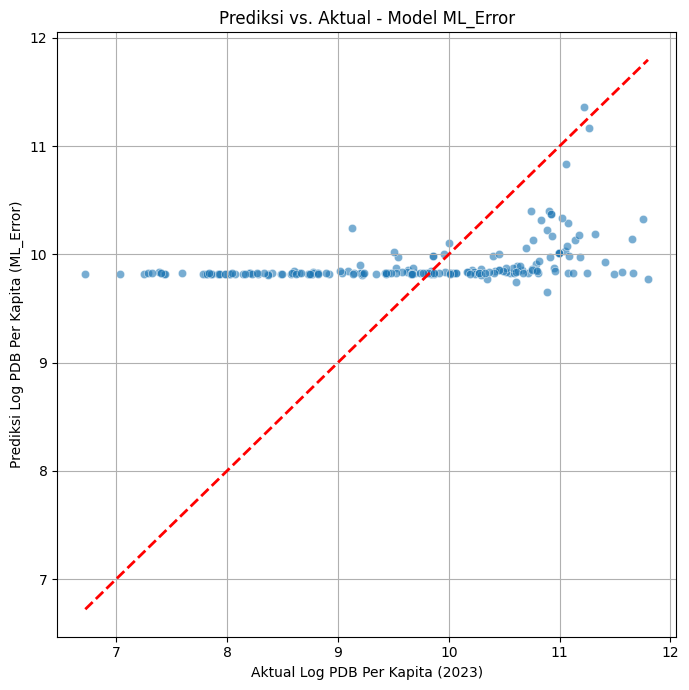

In [68]:
# --- Tahap 10: Visualisasi Hasil Model ---
print("\n--- Visualisasi Hasil Model ---")

# Definisikan warna dan colormap kustom seperti di Tahap 3 (jika belum terdefinisi secara global)
# Jika sudah terdefinisi sebelumnya dalam skrip yang sama, Anda tidak perlu mendefinisikannya ulang.
# Namun, untuk kejelasan, kita bisa definisikan di sini atau pastikan variabelnya ada.

# Warna untuk gradasi fill peta (seperti di Tahap 3)
fill_color_start = '#DC5F00'
fill_color_end = '#CF0A0A'
residual_map_fill_cmap = mcolors.LinearSegmentedColormap.from_list("custom_residual_gradient", [fill_color_start, fill_color_end])

# Warna untuk border peta (seperti di Tahap 3)
map_border_color = '#563298'
map_border_linewidth = 0.5

models_to_visualize = []
# Pastikan kolom residual ada sebelum menambahkannya ke list
if ols_model and 'OLS_Residuals' in merged_gdf.columns:
    models_to_visualize.append({'name': 'OLS', 'res_col': 'OLS_Residuals', 'pred_col': 'OLS_Predicted'})
if ml_lag_model and 'ML_Lag_Residuals' in merged_gdf.columns:
    models_to_visualize.append({'name': 'ML_Lag', 'res_col': 'ML_Lag_Residuals', 'pred_col': 'ML_Lag_Predicted'})
if ml_error_model and 'ML_Error_Residuals' in merged_gdf.columns:
    models_to_visualize.append({'name': 'ML_Error', 'res_col': 'ML_Error_Residuals', 'pred_col': 'ML_Error_Predicted'})

# Peta Residual
print("\nMembuat Peta Residual...")
for model_info in models_to_visualize:
    if model_info['res_col'] in merged_gdf.columns:
        fig, ax = plt.subplots(1, 1, figsize=(15, 10))
        
        # Cek rentang residual untuk legenda yang lebih baik
        # Penting karena colormap sekuensial mungkin tidak secara intuitif menunjukkan nilai negatif/positif
        res_min, res_max = merged_gdf[model_info['res_col']].min(), merged_gdf[model_info['res_col']].max()
        
        # Jika menggunakan colormap sekuensial untuk data divergen (residuals),
        # normalisasi mungkin perlu hati-hati.
        # Untuk konsistensi dengan permintaan, kita gunakan saja colormapnya.
        # Namun, idealnya untuk residual adalah colormap divergen seperti 'coolwarm' atau 'RdBu_r'.
        # norm = plt.Normalize(vmin=res_min, vmax=res_max) # Normalisasi default geopandas biasanya cukup
        
        merged_gdf.plot(column=model_info['res_col'], 
                        ax=ax, 
                        legend=True, 
                        cmap=residual_map_fill_cmap, # Gunakan colormap fill kustom
                        # norm=norm, # Uncomment jika ingin kontrol normalisasi manual
                        edgecolor=map_border_color,      # Gunakan warna border kustom
                        linewidth=map_border_linewidth,  # Gunakan ketebalan border kustom
                        legend_kwds={'label': f"Residuals ({model_info['name']})", 'orientation': "horizontal"})
        
        ax.set_title(f'Peta Residual Model {model_info["name"]} - {latest_year}')
        ax.set_axis_off()
        plt.tight_layout()
        
        # Nama file output untuk peta residual
        residual_map_filename = f"{model_info['name']}_residuals_map_customstyle.png"
        plt.savefig(os.path.join(BASE_DIR, residual_map_filename))
        print(f"Peta residual {model_info['name']} disimpan sebagai {residual_map_filename}")
        # plt.show()
    else:
        print(f"Kolom residual {model_info['res_col']} tidak ditemukan untuk model {model_info['name']}.")

# Plot Prediksi vs. Aktual (bagian ini tidak diminta diubah, jadi tetap sama)
print("\nMembuat Plot Prediksi vs. Aktual...")
for model_info in models_to_visualize:
    if model_info['pred_col'] in merged_gdf.columns and 'Log_GDP_Per_Capita' in merged_gdf.columns:
        fig, ax = plt.subplots(figsize=(7, 7))
        sns.scatterplot(x=merged_gdf['Log_GDP_Per_Capita'], y=merged_gdf[model_info['pred_col']], ax=ax, alpha=0.6)
        
        # Menghitung nilai min dan max untuk garis diagonal y=x
        # Handle kasus jika salah satu kolom kosong atau hanya berisi NaN
        actual_vals = merged_gdf['Log_GDP_Per_Capita'].dropna()
        pred_vals = merged_gdf[model_info['pred_col']].dropna()
        
        if not actual_vals.empty and not pred_vals.empty:
            min_val = min(actual_vals.min(), pred_vals.min())
            max_val = max(actual_vals.max(), pred_vals.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2) # Garis y=x
        
        ax.set_xlabel(f"Aktual Log PDB Per Kapita ({latest_year})")
        ax.set_ylabel(f"Prediksi Log PDB Per Kapita ({model_info['name']})")
        ax.set_title(f"Prediksi vs. Aktual - Model {model_info['name']}")
        ax.grid(True)
        plt.tight_layout()
        
        # Nama file output untuk plot prediksi vs aktual
        pred_actual_filename = f"{model_info['name']}_predicted_vs_actual.png"
        plt.savefig(os.path.join(BASE_DIR, pred_actual_filename))
        print(f"Plot Prediksi vs. Aktual {model_info['name']} disimpan sebagai {pred_actual_filename}")
        # plt.show()
    else:
        print(f"Kolom prediksi {model_info['pred_col']} atau 'Log_GDP_Per_Capita' tidak ditemukan untuk model {model_info['name']}.")

print("\n--- Analisis Selesai (termasuk OLS, SAR, SEM, evaluasi, dan visualisasi dengan gaya peta yang disesuaikan) ---")
print(f"Output dan plot disimpan di direktori: {BASE_DIR}")